## Feature Encoding

Categorical variables were already converted to numeric format in the data wrangling step:

- Room type variables were one-hot encoded (hotel room, private room, shared room)
- Amenities were transformed into binary indicator variables (e.g., `amenity_wifi`, `amenity_pool`)

No additional encoding is needed since they were completed in earlier sections.

## Problem Framing

The goal here is to build and compare machine learning models that predict Airbnb listing demand. Since booking data isn't public, I'm using `reviews_per_month` as a demand proxy, assuming that listings that get booked more tend to accumulate reviews faster.

`reviews_per_month` is a continuous numeric variable, so this is a **regression problem**. The target will be log-transformed to reduce skew before modeling.

**Modeling plan:**
- Start with a simple baseline (Linear Regression, core features only)
- Add amenity features and test regularized linear models (Ridge, Lasso)
- Compare against nonlinear tree models (Random Forest, XGBoost)
- Use cross-validation to confirm stability, then tune the best model
- Select a final model based on error metrics and interpretability

## Imports

In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

## Load Clean Data

In [3]:
df = pd.read_csv('../data/processed/airbnb_preprocessed.csv')

## Inspect Dataset

In [4]:
df.shape

(153594, 82)

In [5]:
df.head()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,amenity_wifi,amenity_workspace,city,price_log,number_of_reviews_log,beds_log,accommodates_log,bedrooms_log,bathrooms_log,room_type
0,108061,320564,0,0,0,2,1.0,1.0,1.0,1.0,...,1,0,Asheville,4.615121,4.532599,0.693147,1.098612,0.693147,0.693147,Entire home/apt
1,155305,746673,0,0,0,2,1.0,1.0,1.0,0.0,...,1,0,Asheville,4.615121,5.950643,0.693147,1.098612,0.693147,0.693147,Entire home/apt
2,156805,746673,0,1,0,2,1.0,1.0,2.5,0.0,...,1,0,Asheville,4.204693,4.219508,0.693147,1.098612,0.693147,1.252763,Private room
3,197263,961396,0,1,0,2,1.0,1.0,1.0,1.0,...,1,1,Asheville,3.828641,4.204693,0.693147,1.098612,0.693147,0.693147,Private room
4,209068,1029919,0,0,0,4,1.0,2.0,1.0,1.0,...,1,1,Asheville,4.615121,4.110874,1.098612,1.609438,0.693147,0.693147,Entire home/apt


In [6]:
df.columns.tolist()

['id',
 'host_id',
 'room_type_hotel_room',
 'room_type_private_room',
 'room_type_shared_room',
 'accommodates',
 'bedrooms',
 'beds',
 'bathrooms',
 'host_is_superhost',
 'host_response_time_ord',
 'price',
 'latitude',
 'longitude',
 'number_of_reviews',
 'reviews_per_month',
 'review_scores_rating',
 'instant_bookable',
 'amenity_air_conditioning',
 'amenity_bathtub',
 'amenity_bbq_grill',
 'amenity_beach_access',
 'amenity_bed_linens',
 'amenity_blender',
 'amenity_carbon_monoxide_alarm',
 'amenity_cleaning_supplies',
 'amenity_coffee_maker',
 'amenity_cooking_basics',
 'amenity_dishwasher',
 'amenity_dryer',
 'amenity_essentials',
 'amenity_ev_charger',
 'amenity_fan',
 'amenity_fire_extinguisher',
 'amenity_fireplace',
 'amenity_first_aid_kit',
 'amenity_flexible_checkin',
 'amenity_game_console',
 'amenity_gym',
 'amenity_hair_dryer',
 'amenity_hangers',
 'amenity_heating',
 'amenity_host_services',
 'amenity_hot_tub',
 'amenity_hot_water',
 'amenity_iron',
 'amenity_kids_ameni

## Exploring `reviews_per_month`

In [7]:
df['reviews_per_month'].describe()

count    153594.000000
mean          1.590251
std           1.856695
min           0.010000
25%           0.310000
50%           1.000000
75%           2.340000
max         101.420000
Name: reviews_per_month, dtype: float64

In [8]:
# How many listings have 0 reviews per month?
zero_count = (df['reviews_per_month'] == 0).sum()
zero_percent = (df['reviews_per_month'] == 0).mean() * 100

print("Listings with 0 reviews_per_month:", zero_count)
print("Percent with 0 reviews_per_month:", round(zero_percent, 2), "%")

Listings with 0 reviews_per_month: 0
Percent with 0 reviews_per_month: 0.0 %


In [9]:
# What are the outliers? 
reviews_95 = df['reviews_per_month'].quantile(0.95)

print("95th percentile for reviews_per_month:", reviews_95)

reviews_95_count = (df['reviews_per_month'] > reviews_95).sum()
reviews_95_percent = (df['reviews_per_month'] > reviews_95).mean() * 100

print("Listings above 95th percentile:", reviews_95_count)
print("Percent above 95th percentile:", round(reviews_95_percent, 2), "%")

95th percentile for reviews_per_month: 4.86
Listings above 95th percentile: 7632
Percent above 95th percentile: 4.97 %


In [10]:
# Manually check listings with high reviews per month
# Could be data errors, duplicated listings, or hotel-style
high_review_listings = df[df['reviews_per_month'] > 50].copy()
print("Listings with reviews_per_month > 50:", high_review_listings.shape[0])

Listings with reviews_per_month > 50: 13


In [11]:
high_review_listings[
    ['id', 'host_id', 'city', 'room_type', 'price',
     'reviews_per_month', 'number_of_reviews',
     'review_scores_rating', 'host_is_superhost',
     'instant_bookable']].sort_values(by='reviews_per_month', ascending=False)

,id,host_id,city,room_type,price,reviews_per_month,number_of_reviews,review_scores_rating,host_is_superhost,instant_bookable
37834,35159128,263748930,Clark County,Private room,228.0,101.42,1146,4.67,0.0,1
118312,54227245,438770271,Nashville,Entire home/apt,117.0,99.19,1425,4.88,1.0,1
131814,53843545,435369966,Nyc,Private room,213.0,86.61,1097,4.45,0.0,1
92952,578174478591578178,253105222,Los Angeles,Private room,132.0,81.19,977,4.29,0.0,0
37814,35158303,263748930,Clark County,Private room,226.0,68.66,1705,4.50,0.0,1
133350,44799007,219517861,Nyc,Entire home/apt,234.0,61.26,1842,4.72,0.0,0
96101,53827863,253105222,Los Angeles,Private room,133.0,59.73,880,4.36,0.0,0
123717,565317486488599327,218602737,New Orleans,Entire home/apt,379.0,58.48,733,4.46,0.0,0
31020,29819757,57387860,Chicago,Hotel room,173.0,58.47,3091,4.52,0.0,1
92298,42409434,229716119,Los Angeles,Entire home/apt,116.0,57.46,2084,4.66,0.0,0


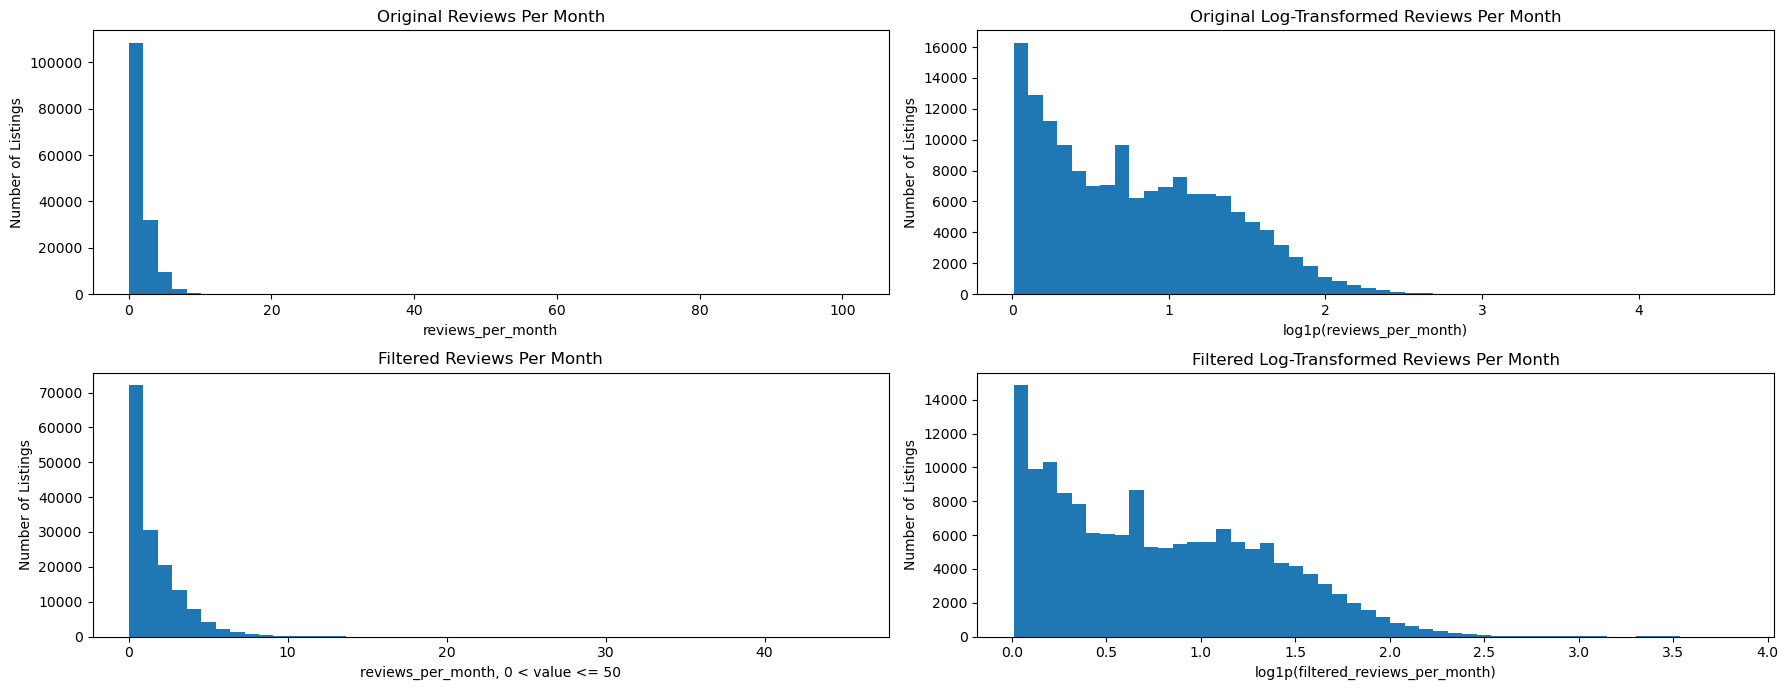

In [12]:
# Compare 4 versions of the target distribution to decide on filtering + transformation
filtered_reviews = df[
    (df['reviews_per_month'] > 0) &
    (df['reviews_per_month'] <= 50)]['reviews_per_month']

fig, axes = plt.subplots(2, 2, figsize=(18, 7))

axes[0, 0].hist(df['reviews_per_month'], bins=50)
axes[0, 0].set_title('Original Reviews Per Month')
axes[0, 0].set_xlabel('reviews_per_month')
axes[0, 0].set_ylabel('Number of Listings')

axes[0, 1].hist(np.log1p(df['reviews_per_month']), bins=50)
axes[0, 1].set_title('Original Log-Transformed Reviews Per Month')
axes[0, 1].set_xlabel('log1p(reviews_per_month)')
axes[0, 1].set_ylabel('Number of Listings')

axes[1, 0].hist(filtered_reviews, bins=50)
axes[1, 0].set_title('Filtered Reviews Per Month')
axes[1, 0].set_xlabel('reviews_per_month, 0 < value <= 50')
axes[1, 0].set_ylabel('Number of Listings')

axes[1, 1].hist(np.log1p(filtered_reviews), bins=50)
axes[1, 1].set_title('Filtered Log-Transformed Reviews Per Month')
axes[1, 1].set_xlabel('log1p(filtered_reviews_per_month)')
axes[1, 1].set_ylabel('Number of Listings')

plt.tight_layout()
plt.show()

## Define Target

The target variable is `reviews_per_month` used as a proxy for listing demand.

The original distribution was heavily right-skewed: the median was only 0.58 reviews per month, but the max was over 100. Before modeling I filtered to active listings only:

- Removed listings with `reviews_per_month == 0` (inactive, no signal)
- Removed listings with more than 50 reviews per month (extreme outliers were generally hotel-style operations confirmed by manual review)

The upper cutoff is intentionally conservative: it removes the largest outliers while keeping high-performing listings. After filtering, the distribution was still skewed, so I applied `np.log1p()` to bring it closer to normal.

In [13]:
df = df[
    (df['reviews_per_month'] > 0) &
    (df['reviews_per_month'] <= 50)].copy()

df['reviews_per_month_log'] = np.log1p(df['reviews_per_month'])

y = df['reviews_per_month_log']

In [14]:
y.describe()

count    153581.000000
mean          0.777405
std           0.564553
min           0.009950
25%           0.270027
50%           0.693147
75%           1.205971
max           3.840097
Name: reviews_per_month_log, dtype: float64

## Select Features

Starting with a small set of core listing features for the baseline model: capacity, location, host status, booking type, and review score. Amenities get added in the next feature set.

In [15]:
features = [
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'latitude',
    'longitude',
    'host_is_superhost',
    'instant_bookable',
    'host_response_time_ord',
    'review_scores_rating']

X = df[features]
X.head()

,accommodates,bedrooms,beds,bathrooms,latitude,longitude,host_is_superhost,instant_bookable,host_response_time_ord,review_scores_rating
0,2,1.0,1.0,1.0,35.60670,-82.55563,1.0,0,3.0,4.51
1,2,1.0,1.0,1.0,35.57864,-82.59578,0.0,0,3.0,4.59
2,2,1.0,1.0,2.5,35.57864,-82.59578,0.0,1,3.0,4.52
3,2,1.0,1.0,1.0,35.57808,-82.63689,1.0,0,2.0,4.95
4,4,1.0,2.0,1.0,35.61856,-82.55276,1.0,0,2.0,4.87


## Train/Test Split

80/20 split. Not a time-series problem, so random split is fine.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Evaluation Function

Built a function so every model gets evaluated the same way. Three metrics:

- **MAE** : average prediction error in log-reviews-per-month units; easiest to explain to stakeholders
- **RMSE** : same idea but punishes larger errors more; better for catching bad predictions
- **R²** : how much variance the model explains; useful for comparison but not the primary decision metric

In [17]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    
    print(model_name)
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R²:", round(r2, 4))
    
    return {"model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

## Baseline: Linear Regression (Core Features Only)

Starting point before adding amenities or trying more complex models.

In [18]:
baseline_model = LinearRegression()

baseline_results = evaluate_regression_model(
    baseline_model, X_train, X_test, y_train, y_test, "Baseline Linear Regression")

Baseline Linear Regression
MAE: 0.4039
RMSE: 0.497
R²: 0.2178


The baseline model explains about 14% of the variation in log reviews per month. Core listing features have some predictive value, but don't tell the whole story. Next step: add amenity features and test more flexible models.

## Amenity Features

Amenities could matter because they imply quality, convenience, and guest experience. But not all amenities are equally useful:

- **Too common** (>95% of listings): nearly every listing has them, so they don't differentiate (wifi, smoke alarm)
- **Too rare** (<5% of listings): not enough examples for the model to learn from (ski access, EV chargers)

Keeping the middle range.

In [19]:
amenity_cols = [col for col in df.columns if col.startswith('amenity_')]

amenity_frequency = df[amenity_cols].mean().sort_values(ascending=False)

amenity_frequency.head(10)

amenity_wifi                0.986287
amenity_smoke_alarm         0.944179
amenity_kitchen             0.910796
amenity_essentials          0.910660
amenity_air_conditioning    0.902520
amenity_tv                  0.900469
amenity_cooking_basics      0.826391
amenity_hangers             0.826183
amenity_refrigerator        0.822654
amenity_hair_dryer          0.815980
dtype: float64

In [20]:
selected_amenities = amenity_frequency[
    (amenity_frequency > 0.05) & (amenity_frequency < 0.95)].index.tolist()

print("Amenities selected:", len(selected_amenities))

Amenities selected: 49


In [21]:
selected_amenities[:20]

['amenity_smoke_alarm',
 'amenity_kitchen',
 'amenity_essentials',
 'amenity_air_conditioning',
 'amenity_tv',
 'amenity_cooking_basics',
 'amenity_hangers',
 'amenity_refrigerator',
 'amenity_hair_dryer',
 'amenity_parking_free',
 'amenity_hot_water',
 'amenity_iron',
 'amenity_toiletries',
 'amenity_heating',
 'amenity_coffee_maker',
 'amenity_carbon_monoxide_alarm',
 'amenity_microwave',
 'amenity_washer',
 'amenity_bed_linens',
 'amenity_dryer']

In [22]:
rare_amenities = amenity_frequency[(amenity_frequency < 0.05)].index.tolist()
rare_amenities

['amenity_view_other',
 'amenity_view_water',
 'amenity_ev_charger',
 'amenity_musical_instruments',
 'amenity_game_console',
 'amenity_ski_access']

## Feature Set With Amenities

Adding the selected amenities to the baseline feature set to create the expanded feature matrix (`X2`). All models from here on use `X2` unless noted.

In [23]:
features_with_amenities = features + selected_amenities

X2 = df[features_with_amenities]

# Use the same train/test indexes as baseline to keep comparisons fair
X2_train = X2.loc[X_train.index]
X2_test = X2.loc[X_test.index]

print("X2_train shape:", X2_train.shape)
print("X2_test shape:", X2_test.shape)

X2_train shape: (122864, 59)
X2_test shape: (30717, 59)


## Feature Correlations With Key Outcomes

Quick heatmap to see which features and amenities correlate most with price, total reviews, reviews per month, and review score.

In [24]:
outcome_cols = ['price', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating']
outcome_cols = [col for col in outcome_cols if col in df.columns]

core_feature_cols = [col for col in features if col in df.columns]
# Make sure outcome cols don't bleed into the feature list
feature_cols_for_corr = [col for col in core_feature_cols + amenity_cols 
                         if col not in outcome_cols]

corr_analysis_df = df[feature_cols_for_corr + outcome_cols].copy()
corr_matrix_full = corr_analysis_df.corr(numeric_only=True)
feature_outcome_corr = corr_matrix_full.loc[feature_cols_for_corr, outcome_cols]

top_features = (
    feature_outcome_corr.abs().max(axis=1)
    .sort_values(ascending=False)
    .head(25).index)

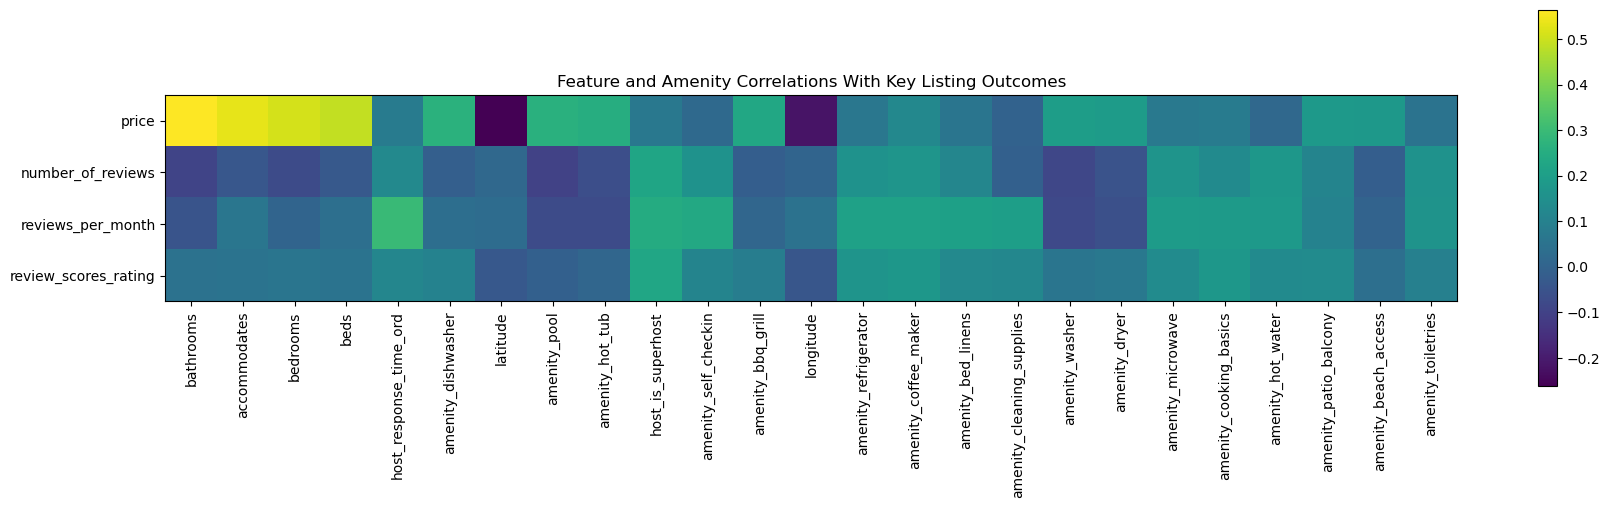

In [25]:
heatmap_corr = feature_outcome_corr.loc[top_features, outcome_cols].T

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(heatmap_corr)

ax.set_xticks(range(len(heatmap_corr.columns)))
ax.set_yticks(range(len(heatmap_corr.index)))
ax.set_xticklabels(heatmap_corr.columns, rotation=90)
ax.set_yticklabels(heatmap_corr.index)

plt.colorbar(im, ax=ax)
ax.set_title('Feature and Amenity Correlations With Key Listing Outcomes')

plt.tight_layout()
plt.show()

## Linear Regression With Amenities

Same algorithm as the baseline, but with the full feature set. Goal is to see whether amenities move the needle before trying more complex models.

In [26]:
linear_amenity_model = LinearRegression()

linear_amenity_results = evaluate_regression_model(
    linear_amenity_model, X2_train, X2_test, y_train, y_test,
    "Linear Regression With Amenities")

Linear Regression With Amenities
MAE: 0.3716
RMSE: 0.4654
R²: 0.3141


## Ridge Regression

Ridge adds L2 regularization to shrink coefficients and reduce overfitting. It's useful since some listing features are correlated (e.g., bedrooms and accommodates). Ridge keeps all features but reduces their influence.

Ridge is sensitive to feature scale, so the pipeline scales first.

In [27]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=42))])

ridge_results = evaluate_regression_model(
    ridge_pipeline, X2_train, X2_test, y_train, y_test, "Ridge Regression")

Ridge Regression
MAE: 0.3716
RMSE: 0.4654
R²: 0.3141


## Lasso Regression

Lasso uses L1 regularization, so some features w/coefficients close to 0 essentially drop. That makes it useful for implicit feature selection, especially with a large amenity set.

In [28]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.001, random_state=42, max_iter=10000))])

lasso_results = evaluate_regression_model(
    lasso_pipeline, X2_train, X2_test, y_train, y_test, "Lasso Regression")

Lasso Regression
MAE: 0.3719
RMSE: 0.4655
R²: 0.3139


## Lasso Feature Selection

Since Lasso zeroed out some coefficients, it's helpful to see the results

In [29]:
lasso_pipeline.fit(X2_train, y_train)

lasso_coefficients = lasso_pipeline.named_steps['model'].coef_

lasso_coeffs = pd.DataFrame({
    'feature': X2.columns,
    'coefficient': lasso_coefficients})

selected_features_lasso = lasso_coeffs[lasso_coeffs['coefficient'] != 0].copy()

selected_features_lasso['abs_coefficient'] = selected_features_lasso['coefficient'].abs()
selected_features_lasso = selected_features_lasso.sort_values(by='abs_coefficient', ascending=False)

selected_features_lasso.head(15)

,feature,coefficient,abs_coefficient
8,host_response_time_ord,0.125700,0.125700
0,accommodates,0.095655,0.095655
6,host_is_superhost,0.069364,0.069364
33,amenity_self_checkin,0.067254,0.067254
3,bathrooms,-0.058076,0.058076
42,amenity_cleaning_supplies,0.046007,0.046007
29,amenity_dryer,-0.045646,0.045646
32,amenity_oven,-0.045198,0.045198
1,bedrooms,-0.037468,0.037468
22,amenity_toiletries,0.036966,0.036966


Accommodates, superhost status, self check-in, bathrooms, and cleaning supplies have the strongest linear associations with demand. Worth noting that without direct booking data these are correlational, not causal.

## Random Forest

Although this is a linear regression problem, I wanted to see how Random Forest would perform and see if we could uncover any additional insights on booking drivers. Specifically it would pick up on nonlinear relationships and interactions between features (e.g., location × room type) without any manual engineering.

In [30]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)

rf_results = evaluate_regression_model(
    rf_model, X2_train, X2_test, y_train, y_test, "Random Forest")

Random Forest
MAE: 0.2865
RMSE: 0.3784
R²: 0.5465


## Random Forest Feature Importance

In [31]:
rf_model.fit(X2_train, y_train)

rf_importance = pd.DataFrame({
    'feature': X2.columns,
    'importance': rf_model.feature_importances_})

rf_importance = rf_importance.sort_values(by='importance', ascending=False)
rf_importance.head(20)

,feature,importance
9,review_scores_rating,0.193904
8,host_response_time_ord,0.162115
5,longitude,0.097292
4,latitude,0.095488
0,accommodates,0.032307
42,amenity_cleaning_supplies,0.028487
24,amenity_coffee_maker,0.020926
3,bathrooms,0.019425
2,beds,0.016659
6,host_is_superhost,0.015383


## XGBoost

XGBoost is more complex than Random Forest and harder to interpret, so I'm treating it as a benchmark to see whether the added complexity is worth it.

In [32]:
xgb_model = XGBRegressor(
    n_estimators=100,
    random_state=42,
    objective='reg:squarederror')

xgb_results = evaluate_regression_model(
    xgb_model, X2_train, X2_test, y_train, y_test, "XGBoost")

XGBoost
MAE: 0.293
RMSE: 0.3826
R²: 0.5364


## Model Comparison

All models evaluated on the same test set. Prioritizing RMSE and MAE since they directly measure prediction error. R² is useful for context but not the deciding factor on its own.

In [33]:
model_results = [
    baseline_results,
    linear_amenity_results,
    ridge_results,
    lasso_results,
    rf_results,
    xgb_results]

model_comparison = pd.DataFrame(model_results)
model_comparison.sort_values(by='RMSE')

,model,MAE,RMSE,R2
4,Random Forest,0.286508,0.378445,0.546452
5,XGBoost,0.293008,0.382598,0.536443
1,Linear Regression With Amenities,0.371602,0.465385,0.314127
2,Ridge Regression,0.371602,0.465385,0.314127
3,Lasso Regression,0.371927,0.465457,0.313915
0,Baseline Linear Regression,0.403890,0.496978,0.217844


## Cross-Validation

One train/test split can be misleading. I used cross-validation on each model 5 times for different slices of the data and reports the average RMSE. The goal is the lowest `mean_cv_rmse`

In [34]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [35]:
def run_cross_validation(models, X, y, cv):
    cv_results = []
    
    for name, model in models.items():
        print(f"Running CV for: {name}")
        
        scores = cross_val_score(
            model, X, y, cv=cv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1)
        
        rmse_scores = -scores
        
        cv_results.append({
            "model": name,
            "mean_cv_rmse": round(rmse_scores.mean(), 4),
            "std_cv_rmse": round(rmse_scores.std(), 4)})
    
    return pd.DataFrame(cv_results).sort_values(by='mean_cv_rmse')

In [36]:
linear_cv_models = {
    "Linear Regression With Amenities": LinearRegression(),
    "Ridge Regression": ridge_pipeline,
    "Lasso Regression": lasso_pipeline}

linear_cv_results = run_cross_validation(linear_cv_models, X2, y, cv)
linear_cv_results

Running CV for: Linear Regression With Amenities
Running CV for: Ridge Regression
Running CV for: Lasso Regression


,model,mean_cv_rmse,std_cv_rmse
0,Linear Regression With Amenities,0.4656,0.0018
1,Ridge Regression,0.4656,0.0018
2,Lasso Regression,0.4657,0.0018


In [37]:
tree_cv_models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model}

tree_cv_results = run_cross_validation(tree_cv_models, X2, y, cv)
tree_cv_results

Running CV for: Random Forest
Running CV for: XGBoost


,model,mean_cv_rmse,std_cv_rmse
0,Random Forest,0.3784,0.0013
1,XGBoost,0.3825,0.0012


## Comparing Models


In [38]:
cv_results_df = pd.concat(
    [linear_cv_results, tree_cv_results],
    ignore_index=True).sort_values(by='mean_cv_rmse')

cv_results_df

,model,mean_cv_rmse,std_cv_rmse
3,Random Forest,0.3784,0.0013
4,XGBoost,0.3825,0.0012
1,Ridge Regression,0.4656,0.0018
0,Linear Regression With Amenities,0.4656,0.0018
2,Lasso Regression,0.4657,0.0018


Tree models outperformed linear models in all folds. 
Random Forest is the strongest candidate for the final model.

## Hyperparameter Tuning

Tuning Random Forest since it had the best CV performance and is easier to interpret than XGBoost. Using a small grid with 3-fold CV to keep runtime down.

**Note:** tuning is run on `X2_train` (with amenities) to match the feature set used for the other models. 

In [39]:
rf_param_grid = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]}

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1)

rf_grid_search.fit(X2_train, y_train)

print("Best parameters:", rf_grid_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [40]:
best_rf = rf_grid_search.best_estimator_

y_pred_rf_tuned = best_rf.predict(X2_test)

mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned) ** 0.5
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest:")
print("MAE:", round(mae_rf_tuned, 4))
print("RMSE:", round(rmse_rf_tuned, 4))
print("R²:", round(r2_rf_tuned, 4))

Tuned Random Forest:
MAE: 0.2894
RMSE: 0.3814
R²: 0.5393


## Final Model Comparison

Adding the tuned Random Forest to the comparison table to see whether tuning moved the needle.

In [41]:
best_rf_results = {
    'model': 'Tuned Random Forest',
    'MAE': mae_rf_tuned,
    'RMSE': rmse_rf_tuned,
    'R2': r2_rf_tuned}

final_model_results = model_results + [best_rf_results]

final_model_comparison = pd.DataFrame(final_model_results)
final_model_comparison.sort_values(by='RMSE')

,model,MAE,RMSE,R2
4,Random Forest,0.286508,0.378445,0.546452
6,Tuned Random Forest,0.289386,0.381407,0.539324
5,XGBoost,0.293008,0.382598,0.536443
1,Linear Regression With Amenities,0.371602,0.465385,0.314127
2,Ridge Regression,0.371602,0.465385,0.314127
3,Lasso Regression,0.371927,0.465457,0.313915
0,Baseline Linear Regression,0.403890,0.496978,0.217844


## Final Model Selection

**Selected model: Tuned Random Forest**

Based on test set performance, cross-validation results, and interpretability:

- Lower error than all linear models across both MAE and RMSE
- Lower standard deviation that XGBoost across CV folds
- Feature importance is easy to explain to non-technical stakeholders
- Captures nonlinear relationships and feature interactions that weren't apparent in linear models

XGBoost performed well, but marginal difference isn't worth the complexity.

## Final Model Feature Importance

Using the tuned Random Forest to get a clean read on which features matter most.

In [42]:
tuned_rf_importance = pd.DataFrame({
    'feature': X2_train.columns,
    'importance': best_rf.feature_importances_})

tuned_rf_importance = tuned_rf_importance.sort_values(by='importance', ascending=False)
tuned_rf_importance.head(20)

,feature,importance
9,review_scores_rating,0.214629
8,host_response_time_ord,0.191342
5,longitude,0.087764
4,latitude,0.085931
42,amenity_cleaning_supplies,0.033378
0,accommodates,0.030027
24,amenity_coffee_maker,0.023431
3,bathrooms,0.017827
6,host_is_superhost,0.017226
33,amenity_self_checkin,0.014136


## Feature Importance Across Models

To see which features show up as important consistently, I ranked each model's top features and built a consensus score. Features that rank highly across multiple models get a stronger score than features that only matter to one model.

This gives a more reliable picture than any single model's importance ranking.

In [43]:
linear_importance = pd.DataFrame({
    'feature': X2.columns,
    'value': linear_amenity_model.coef_})
linear_importance['abs_value'] = linear_importance['value'].abs()
linear_importance = linear_importance.sort_values(by='abs_value', ascending=False).head(15)

ridge_importance = pd.DataFrame({
    'feature': X2.columns,
    'value': ridge_pipeline.named_steps['model'].coef_})
ridge_importance['abs_value'] = ridge_importance['value'].abs()
ridge_importance = ridge_importance.sort_values(by='abs_value', ascending=False).head(15)

lasso_importance = pd.DataFrame({
    'feature': X2.columns,
    'value': lasso_pipeline.named_steps['model'].coef_})
lasso_importance['abs_value'] = lasso_importance['value'].abs()
lasso_importance = lasso_importance.sort_values(by='abs_value', ascending=False).head(15)

rf_importance_final = pd.DataFrame({
    'feature': X2.columns,
    'value': rf_model.feature_importances_})
rf_importance_final = rf_importance_final.sort_values(by='value', ascending=False).head(15)

xgb_importance = pd.DataFrame({
    'feature': X2.columns,
    'value': xgb_model.feature_importances_})
xgb_importance = xgb_importance.sort_values(by='value', ascending=False).head(15)

In [44]:
importance_dfs = {
    'Linear Regression': linear_importance,
    'Ridge Regression': ridge_importance,
    'Lasso Regression': lasso_importance,
    'Random Forest': rf_importance_final,
    'XGBoost': xgb_importance}

ranked_features = []

for model_name, imp_df in importance_dfs.items():
    temp_df = imp_df.copy()
    temp_df['rank'] = temp_df['value'].abs().rank(ascending=False, method='min')
    temp_df = temp_df[['feature', 'rank']]
    temp_df['model'] = model_name
    ranked_features.append(temp_df)

ranked_features_df = pd.concat(ranked_features)

rank_matrix = ranked_features_df.pivot(
    index='feature',
    columns='model',
    values='rank')

rank_matrix['average_rank'] = rank_matrix.mean(axis=1)
rank_matrix = rank_matrix.sort_values(by='average_rank')
rank_matrix_plot = rank_matrix.drop(columns='average_rank')

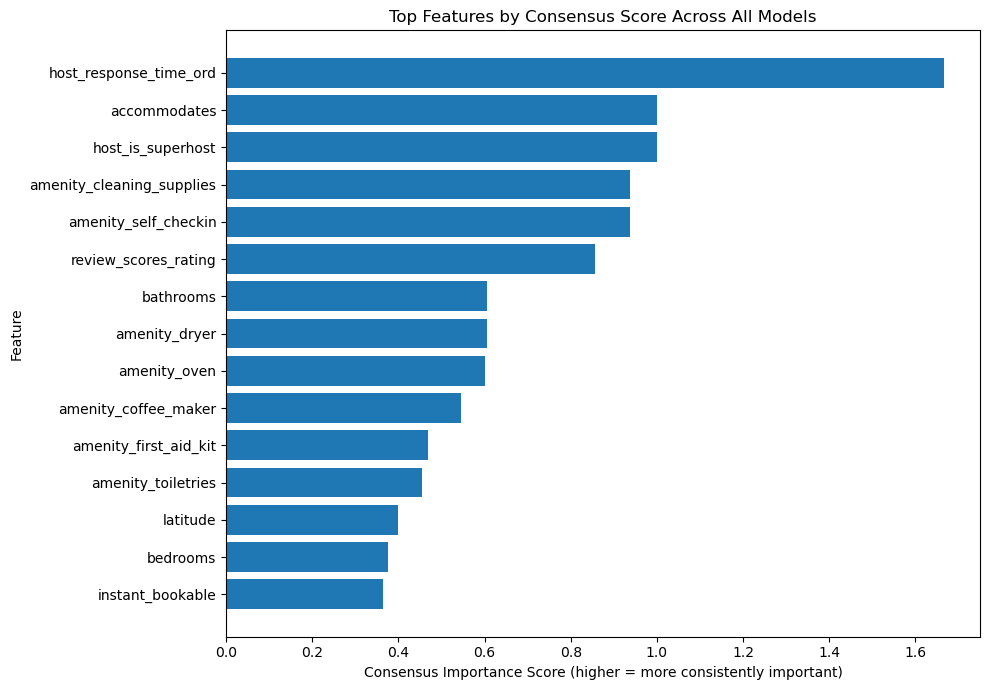

In [45]:
overall_feature_rankings = rank_matrix_plot.copy()

overall_feature_rankings['model_count'] = overall_feature_rankings.notna().sum(axis=1)
overall_feature_rankings['average_rank'] = overall_feature_rankings.mean(axis=1)

# Consensus score: features that rank highly across multiple models score highest
overall_feature_rankings['consensus_score'] = (
    overall_feature_rankings['model_count'] / overall_feature_rankings['average_rank'])

overall_feature_rankings = overall_feature_rankings.sort_values(
    by='consensus_score', ascending=False)

top_overall_features = overall_feature_rankings.head(15).reset_index()

plt.figure(figsize=(10, 7))
plt.barh(top_overall_features['feature'], top_overall_features['consensus_score'])
plt.gca().invert_yaxis()
plt.title('Top Features by Consensus Score Across All Models')
plt.xlabel('Consensus Importance Score (higher = more consistently important)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Stakeholder Summary

The final model predicts log-transformed `reviews_per_month`

This version uses the clean demand dataset, so listings with missing or zero `reviews_per_month` were already removed before modeling. I also filtered out extreme high-demand listings above 50 reviews per month so hotel-style or unusual listings would not dominate the model.

### What seems to matter most

Across the models, the strongest demand signals were:

- **Location:** latitude and longitude helped capture neighborhood-level demand patterns.
- **Capacity and layout:** accommodates, bedrooms, beds, and bathrooms were important.
- **Host and trust signals:** Superhost status, instant booking, response time, and review score helped explain demand.
- **Amenities:** selected amenities added some value, but they were not strong enough on their own.
- **Nonlinear patterns:** Random Forest performed best because demand seems shaped by combinations of location, price, capacity, host quality, and amenities.

### Final model choice

I selected the tuned Random Forest because it performed better than the linear models and was still easier to explain than XGBoost.

The model is not perfect, but it gives a useful baseline for understanding which listing features are tied to stronger demand.

## Next Steps

Now that I have a final demand model, the next step is to make the analysis more useful for real listing decisions.

### 1. Build location-based recommendations

I want to use the model to test which listing types might perform best for a specific latitude and longitude. The idea is to compare different listing scenarios in the same location, such as:

- Studio or 1-bedroom stay
- 2-bedroom family-friendly stay
- Larger group stay
- Work-friendly stay
- Higher-amenity stay

This will help answer the main business question: what type of listing seems most competitive in a given location?

### 2. Compare predictions to local comps

The model recommendation should be checked against real nearby listings. I will filter listings within a set radius and compare the strongest local performers by:

- Reviews per month
- Room type
- Bedrooms and bathrooms
- Accommodates
- Price
- Amenities
- Product score or segment

### 3. Add image analysis

The next extension is to test whether listing images add useful demand signals. I want to start simple by using the main listing image and extracting features like brightness, sharpness, colorfulness, image size, and possibly room or view tags.

Then I can compare the tabular model against a model with image features added.

### 4. Improve the demand signal later

`reviews_per_month` is still an imperfect proxy. It does not show actual bookings, occupancy, or revenue. If booking or occupancy data became available, that would be a much stronger target.